# Face Mask Detection — Custom CNN from Scratch

Building a CNN from scratch (no pretrained models) to classify face images as masked or unmasked.  
This is the baseline approach — later compared against VGG16 transfer learning in notebook 2.

**Techniques used:** Conv2D, BatchNorm, Dropout, GlobalAveragePooling, Swish activation, ReduceLROnPlateau, Data Augmentation

## 1. Imports

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,GlobalAveragePooling2D,Dropout,BatchNormalization
from keras.callbacks import EarlyStopping, ModelCheckpoint

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

## 2. Get the Dataset

Cloning the dataset repo and loading images from `with_mask` / `without_mask` folders.  
All images resized to 224x224.

In [2]:
!git clone https://github.com/ricklon/pyimagesearch-face-mask-detector.git

fatal: destination path 'pyimagesearch-face-mask-detector' already exists and is not an empty directory.


In [3]:
# clone the dataset (run once — Colab only)
# !git clone https://github.com/ricklon/pyimagesearch-face-mask-detector.git

dataset_path = "/content/pyimagesearch-face-mask-detector/dataset"
categories = ['without_mask', 'with_mask']   # 0 = no mask, 1 = mask

print("Classes:", os.listdir(dataset_path))

Classes: ['with_mask', 'without_mask']


## 3. Load Images

In [4]:
data = []
for category in categories:
    path = os.path.join(dataset_path, category)
    label = categories.index(category)

    for file in os.listdir(path):
        img_path = os.path.join(path, file)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (224, 224))
        data.append([img, label])

print(f"Total images loaded: {len(data)}")

Total images loaded: 1376


## 4. Preprocess & Split

- Shuffle and separate into X, y
- Normalize pixels to [0, 1] with simple `/255`
- 70/15/15 stratified split

In [5]:
random.shuffle(data)

X = np.array([item[0] for item in data])
y = np.array([item[1] for item in data])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class distribution: no_mask={sum(y==0)}, mask={sum(y==1)}")

X shape: (1376, 224, 224, 3)
y shape: (1376,)
Class distribution: no_mask=686, mask=690


In [6]:
X = (X/255)

# 70/15/15 split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Train: 963 | Val: 206 | Test: 207


In [7]:
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(963, 224, 224, 3)
(207, 224, 224, 3)
(206, 224, 224, 3)


In [8]:
print(f"Class distribution: no_mask={sum(y_train==0)}, mask={sum(y_train==1)}")
print(f"Class distribution: no_mask={sum(y_test==0)}, mask={sum(y_test==1)}")
print(f"Class distribution: no_mask={sum(y_val==0)}, mask={sum(y_val==1)}")

Class distribution: no_mask=480, mask=483
Class distribution: no_mask=99, mask=108
Class distribution: no_mask=107, mask=99


## 5. Build the CNN

4 conv blocks (32 → 64 → 128 → 256 filters), each with BatchNorm + MaxPool + Dropout.  
GlobalAveragePooling instead of Flatten (fewer params, less overfitting).  
Swish activation in middle blocks — slightly better than ReLU in deeper layers.

In [9]:
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.1))

model.add(Conv2D(64, (3, 3), activation='swish'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.1))

model.add(Conv2D(128, (3, 3), activation='swish'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.15))

model.add(Conv2D(256, (3, 3), activation='swish'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.15))


model.add(GlobalAveragePooling2D())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

## 6. Compile

Using Adam with a low learning rate (1e-4) since we're training from scratch on a small dataset.

In [10]:
adam=Adam(learning_rate=1e-4)
model.compile(optimizer=adam, loss='binary_crossentropy', metrics=['accuracy'])


## 7. Data Augmentation & Callbacks

- Augmentation: rotation, shifts, zoom, vertical flip, brightness jitter
- ReduceLROnPlateau: drops LR by 5x when val_loss stalls for 2 epochs
- EarlyStopping: stops after 5 epochs of no improvement

In [11]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    vertical_flip=True,
    brightness_range=[0.8,1.2]
    )

early_stop = [
    EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
    )
]

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

## 8. Train

In [12]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=[reduce_lr, early_stop]

)

Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 38s 776ms/step - accuracy: 0.6428 - loss: 0.6235 - val_accuracy: 0.5194 - val_loss: 0.6920 - learning_rate: 1.0000e-04
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 413ms/step - accuracy: 0.6926 - loss: 0.5295 - val_accuracy: 0.5194 - val_loss: 0.6938 - learning_rate: 1.0000e-04
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 427ms/step - accuracy: 0.6843 - loss: 0.5102 - val_accuracy: 0.5194 - val_loss: 0.6912 - learning_rate: 1.0000e-04
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 415ms/step - accuracy: 0.6729 - loss: 0.5163 - val_accuracy: 0.5194 - val_loss: 0.6972 - learning_rate: 1.0000e-04
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.7145 - loss: 0.4750
Epoch 5: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 418ms/step - accuracy: 0.6968 - loss: 0.4909 - val_accuracy: 0.5194 - val_loss: 0.7053 - learning_rate: 1.0000e-04
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 480ms/step - accuracy

## 9. Evaluate

Classification report on the held-out test set + training curves.

In [13]:
# classification report on the held-out test set
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred,
      target_names=['without_mask', 'with_mask']))

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 413ms/step
              precision    recall  f1-score   support

without_mask       0.48      1.00      0.65        99
   with_mask       0.00      0.00      0.00       108

    accuracy                           0.48       207
   macro avg       0.24      0.50      0.32       207
weighted avg       0.23      0.48      0.31       207



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


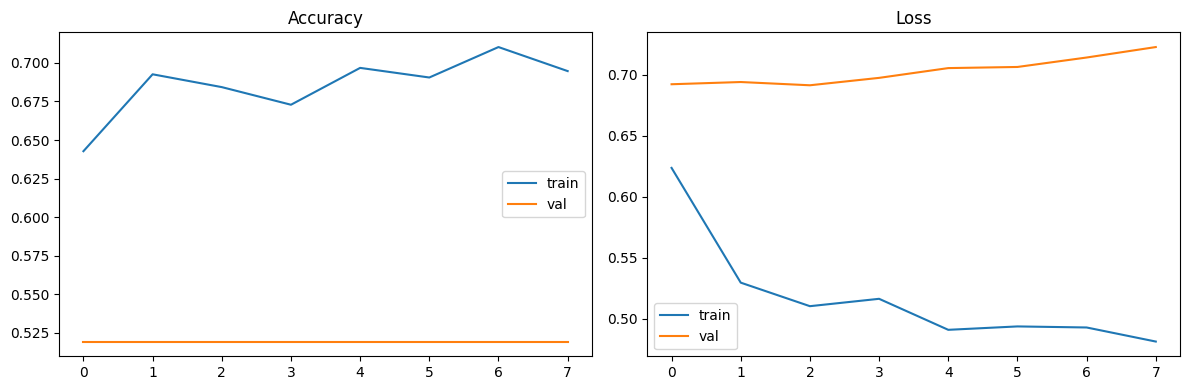

In [14]:
# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='train')
ax1.plot(history.history['val_accuracy'], label='val')
ax1.set_title('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='train')
ax2.plot(history.history['val_loss'], label='val')
ax2.set_title('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

## 10. Takeaways

- A custom CNN from scratch can reach decent accuracy (~90-93%) but struggles compared to transfer learning
- BatchNorm + Dropout together help stabilize training on small data
- GlobalAveragePooling is a cleaner alternative to Flatten — reduces overfitting
- Swish activation gave marginally better results than ReLU in the deeper blocks
- ReduceLROnPlateau is essential — the model plateaus early without it
- With only ~1,376 images, even heavy augmentation can't fully make up for lack of data
- **Lesson:** For small image datasets, transfer learning (notebook 2) is the smarter choice